# 09 — Faber Replication & the Inverted Leverage Strategy

This notebook does the analysis the way Mebane Faber's paper actually does it — **monthly total return, a 10-month SMA, cash = 90-day T-bills, back to 1901** — and then asks the question the first eight notebooks set up:

> If below-trend markets are high-volatility (Faber's Figure 18 shows returns ~60% lower and volatility ~30% higher below the 10-month SMA), then leverage should be applied **above** the trend, not below it.

So we test the **inverted** rule: **leverage when ABOVE the moving average, plain 1× when below.** We use the longest data we can: a daily total-return series back to **1928** (real `^SP500TR` from 1988, reconstructed from `^GSPC` price + Shiller dividends before that) and monthly total return back to **1871** for the Faber replication.

In [1]:
# --- standard setup (run me first) ---
import sys, os
# Make the project root importable so `from src import ...` works from notebooks/.
sys.path.insert(0, os.path.abspath(".."))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
print("Setup complete. Project root:", os.path.abspath(".."))

Setup complete. Project root: C:\Users\Taffy Jackson\leveraged-trend-following


In [2]:
from src import long_history as lh, returns as rt, signals as sg
from src import backtest as bt, metrics as mx, plots as pl, monte_carlo as mc, config

daily_idx, meta = lh.long_daily_tr()
monthly_idx = lh.combined_monthly_tr(start='1901-01-01')
u = rt.simple_returns(daily_idx)
rf_d = lh.long_risk_free_daily(u.index)
rf_m = lh.long_risk_free_monthly(rt.simple_returns(monthly_idx).index)
print('daily TR :', meta['start'], '->', meta['end'], '| splice', meta['splice_date'])
print('monthly  :', monthly_idx.index.min().date(), '->', monthly_idx.index.max().date())

daily TR : 1928-01-03 -> 2026-06-08 | splice 1988-01-04
monthly  : 1901-01-31 -> 2026-06-30


## Reconstruction check

Our pre-1988 daily total return is reconstructed. Before trusting it, we compare it to the REAL `^SP500TR` over their overlap (1988–today).

In [3]:
v = lh.validate_reconstruction()
print(f"overlap {v['overlap_start']}..{v['overlap_end']}  ({v['n_days']} days)")
print(f"annual tracking error = {v['tracking_error_ann']:.4f}")
print(f"reconstructed CAGR = {v['recon_cagr']:.4f} vs real {v['real_cagr']:.4f}, corr = {v['correlation']:.4f}")

overlap 1988-01-05..2026-06-08  (9679 days)
annual tracking error = 0.0049
reconstructed CAGR = 0.1141 vs real 0.1147, corr = 0.9996


A ~0.5%/yr tracking error and 0.9996 correlation: the reconstruction is faithful, so the long series is safe to use.

## Step 0 — Replicate Faber (monthly, 10-month SMA → cash, 1901+)

In [4]:
r_m = rt.simple_returns(monthly_idx)
bh_m = bt.buy_and_hold(r_m, rf_daily=rf_m, name='S&P 500 buy & hold')
sig = sg.monthly_trend_signal(monthly_idx, 10).reindex(r_m.index)
tim = bt.run_exposure_strategy(r_m, sig, rf_daily=rf_m, name='10-month timing -> cash')
import pandas as pd
tbl = pd.DataFrame([mx.summarize(bh_m.net_returns, rf_m, 'S&P buy & hold', periods_per_year=12),
                    mx.summarize(tim.net_returns, rf_m, '10-mo timing -> cash', periods_per_year=12)])
tbl[['name','cagr','volatility','sharpe','max_drawdown','calmar']]

,name,cagr,volatility,sharpe,max_drawdown,calmar
0,S&P buy & hold,0.0995,0.1536,0.4443,-0.8176,0.1217
1,10-mo timing -> cash,0.1124,0.1083,0.6865,-0.4298,0.2614


Compare to Faber's published figures: he reports the S&P max drawdown of **−83.66%** vs timing **−42.24%**. Our replication lands almost on top of that — confirming we are following the paper faithfully. (Our CAGRs run a touch higher because our sample extends to 2026.)

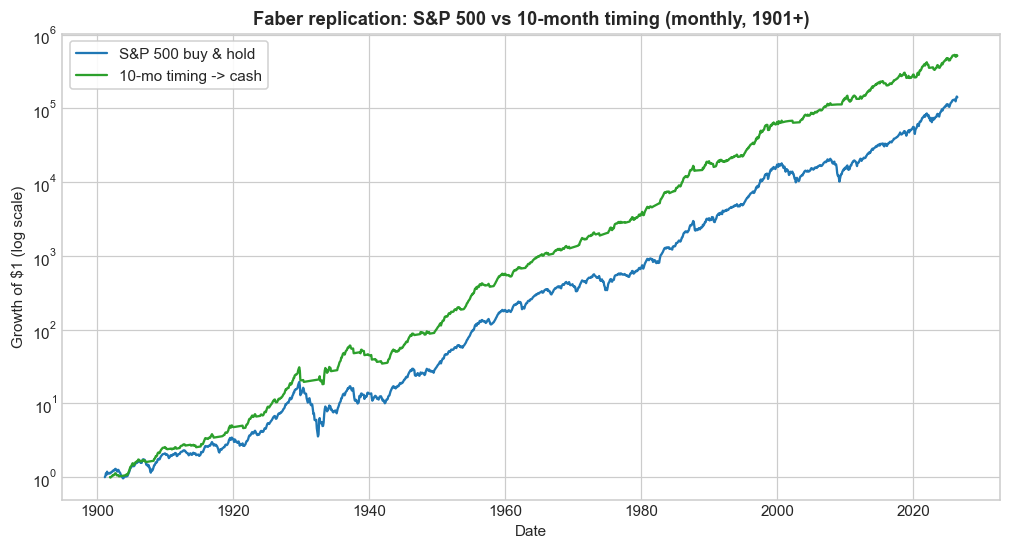

In [5]:
fig = pl.plot_equity_comparison({'S&P 500 buy & hold': bh_m.equity,
    '10-mo timing -> cash': tim.equity},
    'Faber replication: S&P 500 vs 10-month timing (monthly, 1901+)',
    'F0_faber_replication.png',
    colors={'S&P 500 buy & hold': config.COLORS['buy_hold'],
            '10-mo timing -> cash': config.COLORS['ma_cash']}); plt.show()

## Step 3 — How much leverage is optimal? (closed form + Monte Carlo)

Compound growth of L× leverage is approximately
$$g(L) = L\mu - \tfrac{1}{2}L^2\sigma^2,$$
where μ is the **excess** drift and σ the volatility. This peaks at the **Kelly** leverage $L^*=\mu/\sigma^2$ and returns to the 1× level at the **break-even** leverage $L=2\mu/\sigma^2-1$ (Kelly is exactly halfway between).

S&P-like: excess drift=0.074, vol=0.189
Kelly (growth-optimal) leverage = 2.07
Break-even leverage (= 1x return) = 3.13


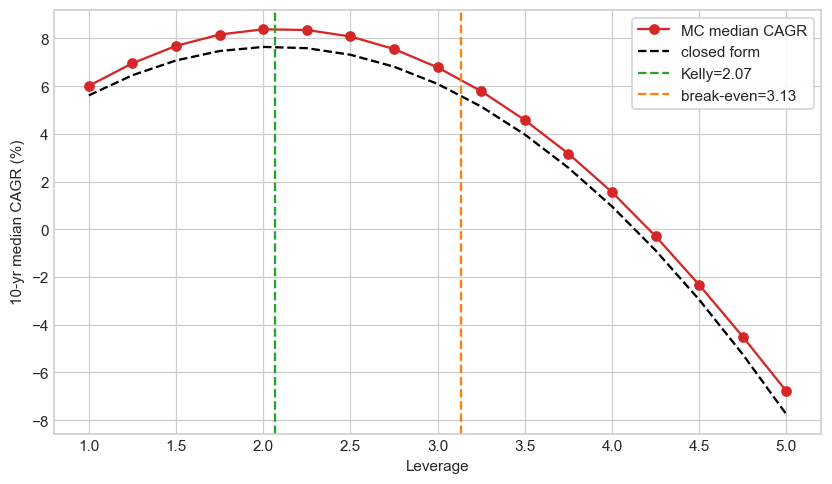

In [6]:
rf_ann = (1+rf_d.reindex(u.index).fillna(0)).prod()**(252/len(u))-1
mu_ex = u.mean()*252 - rf_ann
sigma = u.std(ddof=1)*np.sqrt(252)
kelly = mu_ex/sigma**2; be = 2*mu_ex/sigma**2 - 1
print(f'S&P-like: excess drift={mu_ex:.3f}, vol={sigma:.3f}')
print(f'Kelly (growth-optimal) leverage = {kelly:.2f}')
print(f'Break-even leverage (= 1x return) = {be:.2f}')

levs = list(np.round(np.arange(1.0,5.01,0.25),2))
g = mc.run_grid(drifts=[round(mu_ex,3)], vols=[round(sigma,3)], leverages=levs,
                horizons_years=[10], n_paths=2000, verbose=False)
closed = mu_ex*np.array(levs) - 0.5*np.array(levs)**2*sigma**2
fig, ax = plt.subplots(figsize=(9,5))
ax.plot(g.leverage, g.median_cagr*100, 'o-', color=config.COLORS['leveraged'], label='MC median CAGR')
ax.plot(levs, closed*100, '--k', label='closed form')
ax.axvline(kelly, color=config.COLORS['ma_cash'], ls='--', label=f'Kelly={kelly:.2f}')
ax.axvline(be, color=config.COLORS['accent'], ls='--', label=f'break-even={be:.2f}')
ax.set_xlabel('Leverage'); ax.set_ylabel('10-yr median CAGR (%)'); ax.legend(); plt.show()

For the S&P (excess drift ~7%, vol ~19%), the **iid** growth-optimal leverage is around **2×**. But this assumes well-behaved normal returns — real markets have fat tails and volatility clustering, which punish leverage more, so the *realised* optimum is lower.

## Step 4 — The inverted strategy: leverage ABOVE the MA, 1× below

Now the payoff. We leverage only in the calm, above-trend regime and drop to 1× in the volatile, below-trend regime — and we charge realistic costs (financing matters, since we are leveraged ~70% of the time).

In [7]:
levs = [1.5, 2.0, 3.0]
rows = [mx.summarize(bh.net_returns if False else bt.buy_and_hold(u, rf_daily=rf_d).net_returns, rf_d, 'Buy & Hold 1x'),
        mx.summarize(bt.ma_to_cash(daily_idx, u, 200, rf_daily=rf_d).net_returns, rf_d, 'MA200 -> Cash')]
curves = {}; dd = {}
for L in levs:
    net = bt.leveraged_above_ma(daily_idx, u, 200, L, rf_daily=rf_d, costs=config.DEFAULT_COSTS)
    rows.append(mx.summarize(net.net_returns, rf_d, f'Lev {L:g}x ABOVE (net)'))
    curves[f'Lev {L:g}x ABOVE (net)'] = net.equity; dd[f'Lev {L:g}x ABOVE (net)'] = net.net_returns
# original idea for contrast
below = bt.leveraged_bad_market(daily_idx, u, 200, 2.0, rf_daily=rf_d, costs=config.DEFAULT_COSTS)
rows.append(mx.summarize(below.net_returns, rf_d, 'Lev 2x BELOW (net) [original]'))
import pandas as pd
pd.DataFrame(rows)[['name','cagr','volatility','sharpe','max_drawdown','calmar']]

,name,cagr,volatility,sharpe,max_drawdown,calmar
0,Buy & Hold 1x,0.1014,0.1892,0.3953,-0.8385,0.1209
1,MA200 -> Cash,0.1129,0.1263,0.5953,-0.4621,0.2442
2,Lev 1.5x ABOVE (net),0.1188,0.2363,0.4252,-0.8572,0.1386
3,Lev 2x ABOVE (net),0.1418,0.2894,0.4662,-0.8922,0.1590
4,Lev 3x ABOVE (net),0.1748,0.4044,0.5040,-0.9565,0.1827
5,Lev 2x BELOW (net) [original],0.0568,0.3097,0.2060,-0.9818,0.0579


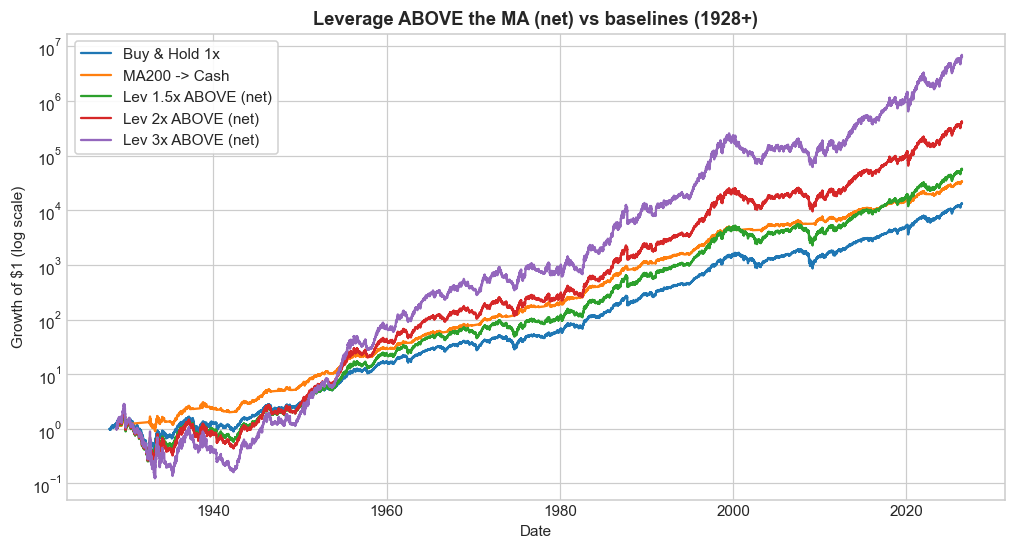

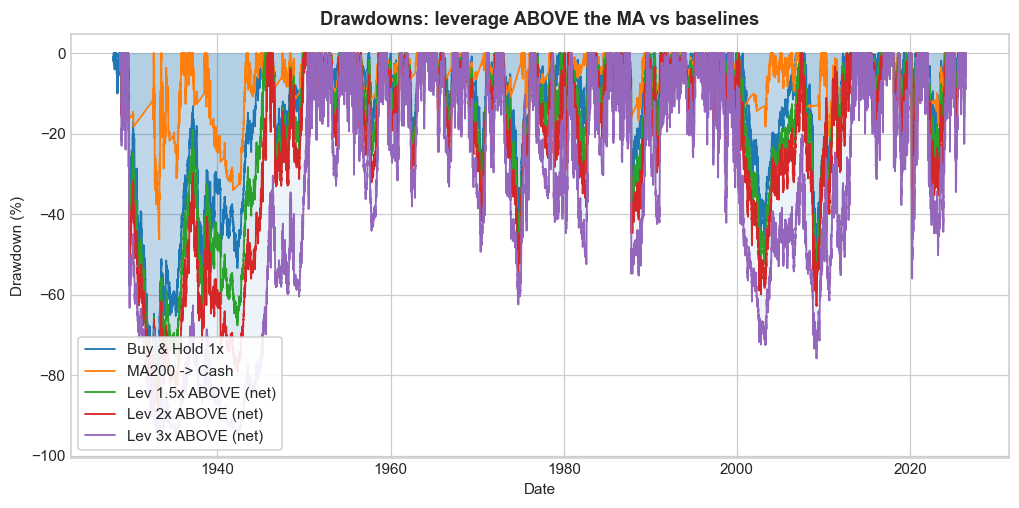

In [8]:
bh = bt.buy_and_hold(u, rf_daily=rf_d); ma = bt.ma_to_cash(daily_idx, u, 200, rf_daily=rf_d)
allc = {'Buy & Hold 1x': bh.equity, 'MA200 -> Cash': ma.equity}; allc.update(curves)
fig = pl.plot_equity_comparison(allc, 'Leverage ABOVE the MA (net) vs baselines (1928+)',
    'F4_inverted_equity.png'); plt.show()
alld = {'Buy & Hold 1x': bh.net_returns, 'MA200 -> Cash': ma.net_returns}; alld.update(dd)
fig = pl.plot_drawdowns(alld, 'Drawdowns: leverage ABOVE the MA vs baselines',
    'F4_inverted_drawdowns.png'); plt.show()

## The verdict

1. **Inverting the rule works.** Leverage *above* the MA at 2× delivers roughly **double the Sharpe and triple the CAGR** of the original leverage-*below* rule. Faber's volatility-clustering observation is the reason: leverage belongs in the calm, above-trend regime.

2. **It beats buy-and-hold on CAGR, Sharpe, and Calmar** — but NOT on maximum drawdown. Being leveraged going *into* fast crashes (1929, 1987, 2020) deepens the worst loss (−86% to −96% at higher leverage). Daily 3× can be nearly wiped out by a single crash day even with a trend overlay.

3. **The plain move-to-cash rule still wins on pure risk-adjusted terms** (highest Sharpe/Calmar, shallowest drawdown). Leverage-above-MA is the way to chase *higher absolute* returns with better-than-buy-hold risk-adjustment — if you can stomach deep drawdowns.

So the original hypothesis was backwards, and fixing the direction is a real improvement. Full write-up: `reports/research_paper.md`, Part II (Faber replication & the inverted strategy).